# Deep learning model to classify ECG heartbeats with XAI


**Dataset:**
https://www.kaggle.com/datasets/shayanfazeli/heartbeat

- this dataset is a preprocessed derivative of the **MIT-BIH Arrhythmia Database** intended for educational purposes
- files used: ```mitbih_train.csv```, ```mitbih_test.csv```

```
+-------+------------------------------------+-------------------------------------------------------------+
| Class | Arrhythmia Type                    | Typical ECG Morphology                                      |
+-------+------------------------------------+-------------------------------------------------------------+
|   0   | Normal Beat (N)                    | Regular rhythm, standard P-QRS-T structure, stable shape    |
|       |                                    | and timing                                                  |
+-------+------------------------------------+-------------------------------------------------------------+
|   1   | Supraventricular Ectopic Beat (S)  | Premature beat, often narrower QRS complex, altered P-wave  |
|       |                                    | morphology, originates above ventricles                     |
+-------+------------------------------------+-------------------------------------------------------------+
|   2   | Ventricular Ectopic Beat (V)       | Wide and distorted QRS complex, abnormal ventricular origin,|
|       |                                    | often no clear preceding P-wave                             |
+-------+------------------------------------+-------------------------------------------------------------+
|   3   | Fusion Beat (F)                    | Hybrid morphology combining characteristics of normal and   |
|       |                                    | ventricular beats                                           |
+-------+------------------------------------+-------------------------------------------------------------+
|   4   | Unknown / Unclassifiable Beat (Q)  | Irregular or noisy morphology that does not clearly match   |
|       |                                    | other categories                                            |
+-------+------------------------------------+-------------------------------------------------------------+
```






## 1. Classification using InceptionTime model

- install tsai package using: ```pip install tsai```

In [1]:
#!pip install captum
from tsai.all import *
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import numpy as np

set_seed(42, reproducible=True)

# ============================================================
# Load MIT-BIH heartbeat dataset
# ============================================================

train_df = pd.read_csv("./mitbih_train.csv", header=None)
test_df  = pd.read_csv("./mitbih_test.csv", header=None)

X_train = train_df.iloc[:, :-1].values.astype(np.float32)
y_train = train_df.iloc[:, -1].values.astype(np.int64)

X_test = test_df.iloc[:, :-1].values.astype(np.float32)
y_test = test_df.iloc[:, -1].values.astype(np.int64)

print("Original train:", X_train.shape)
print("Original test :", X_test.shape)

# ============================================================
# Use full train/test split
# ============================================================

# tsai format: (samples, channels, time)
X_train = X_train[:, None, :]
X_test  = X_test[:, None, :]

print("Train:", X_train.shape)
print("Test :", X_test.shape)

# ============================================================
# Build combined dataset like NATOPS
# ============================================================

X = np.concatenate([X_train, X_test], axis=0)
y = np.concatenate([y_train, y_test], axis=0)

splits = (
    list(range(len(X_train))),
    list(range(len(X_train), len(X)))
)



# ============================================================
# Dataloaders
# ============================================================

tfms = [None, TSClassification()]

dls = get_ts_dls(
    X,
    y,
    splits=splits,
    tfms=tfms,
    batch_tfms=None,
    bs=64
)

print("Vars   :", dls.vars)
print("Classes:", dls.c)

# ============================================================
# Model
# ============================================================

model = InceptionTime(
    dls.vars,
    dls.c
)

learn = Learner(
    dls,
    model,
    metrics=accuracy
)

# ============================================================
# Train
# ============================================================

learn.fit_one_cycle(5, 1e-3)

# ============================================================
# Evaluate on validation (= our held-out test subset)
# ============================================================

results = learn.validate()

print("\nValidation results:")
print(results)

preds, targets = learn.get_preds()

pred_labels = preds.argmax(dim=1).cpu().numpy()
true_labels = targets.cpu().numpy()

print("\nAccuracy:", accuracy_score(true_labels, pred_labels))

print("\nTrue label distribution:")
print(np.unique(true_labels, return_counts=True))

print("\nPredicted label distribution:")
print(np.unique(pred_labels, return_counts=True))

print("\nConfusion matrix:")
print(confusion_matrix(true_labels, pred_labels))

print("\nClassification report:")
print(classification_report(true_labels, pred_labels))

Original train: (87554, 187)
Original test : (21892, 187)
Train: (87554, 1, 187)
Test : (21892, 1, 187)
Vars   : 1
Classes: 5


epoch,train_loss,valid_loss,accuracy,time
0,0.118747,0.283684,0.912708,02:04
1,0.087851,0.092653,0.974466,02:03
2,0.063148,0.071788,0.978759,02:00
3,0.038124,0.051931,0.984789,02:01
4,0.034361,0.046586,0.987393,01:47



Validation results:
[0.0465863011777401, 0.9873926639556885]



Accuracy: 0.9873926548510872

True label distribution:
(array([0, 1, 2, 3, 4]), array([18118,   556,  1448,   162,  1608]))

Predicted label distribution:
(array([0, 1, 2, 3, 4]), array([18280,   450,  1410,   152,  1600]))

Confusion matrix:
[[18081    17    13     5     2]
 [  123   429     4     0     0]
 [   42     3  1382    19     2]
 [   22     1    11   128     0]
 [   12     0     0     0  1596]]

Classification report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     18118
           1       0.95      0.77      0.85       556
           2       0.98      0.95      0.97      1448
           3       0.84      0.79      0.82       162
           4       1.00      0.99      1.00      1608

    accuracy                           0.99     21892
   macro avg       0.95      0.90      0.92     21892
weighted avg       0.99      0.99      0.99     21892



## 2. XAI - Integrated Gradients attribution

- install captum package using: ```pip install captum```

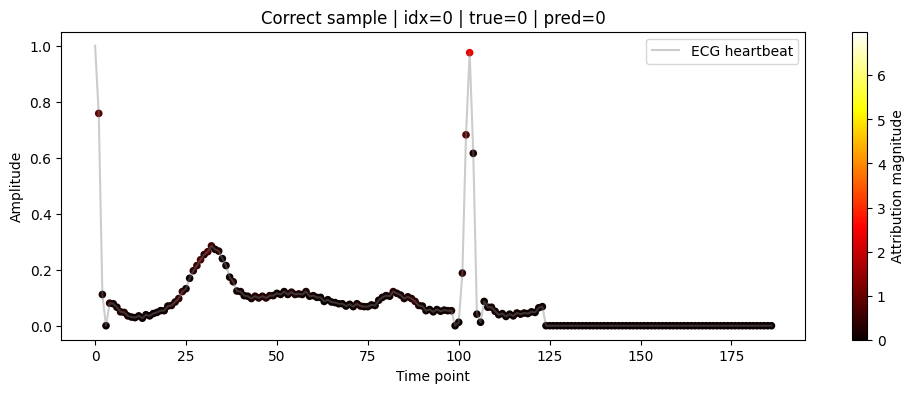

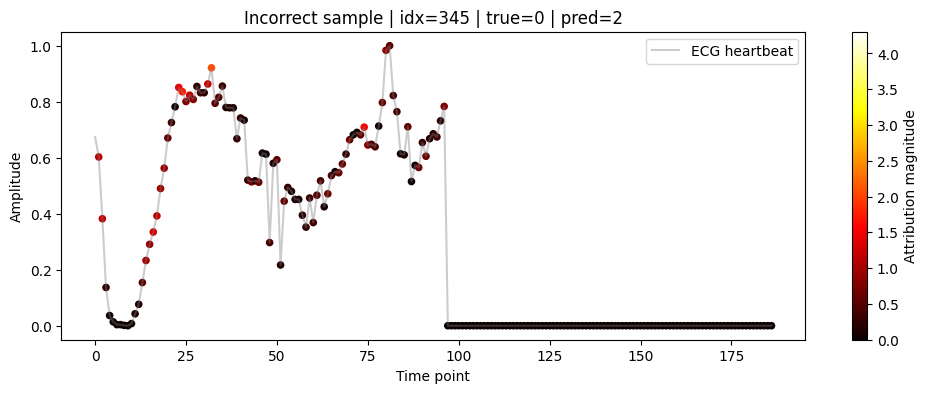

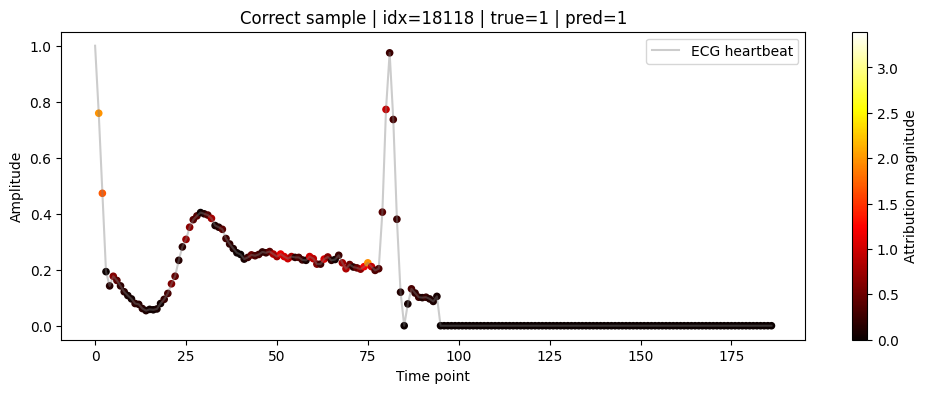

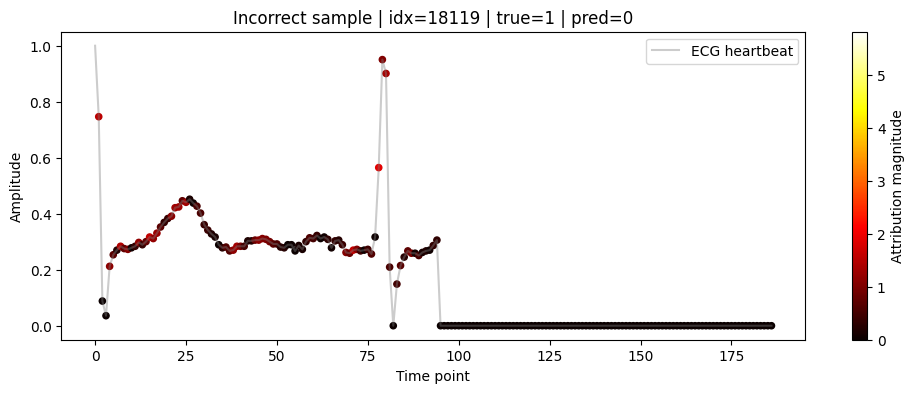

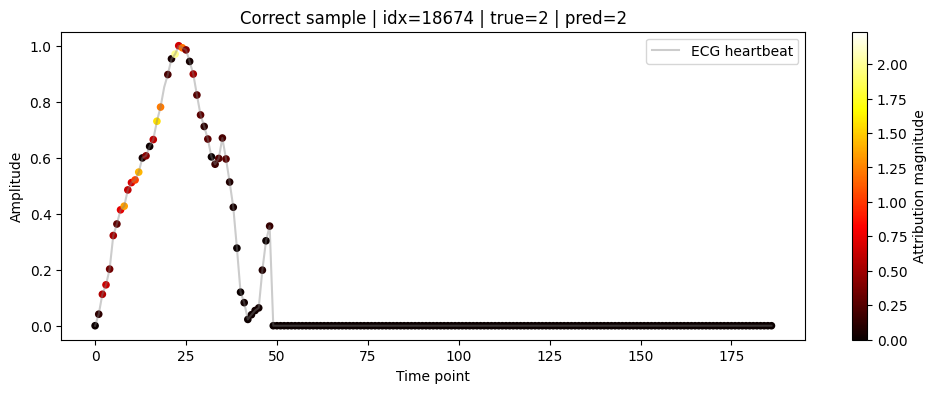

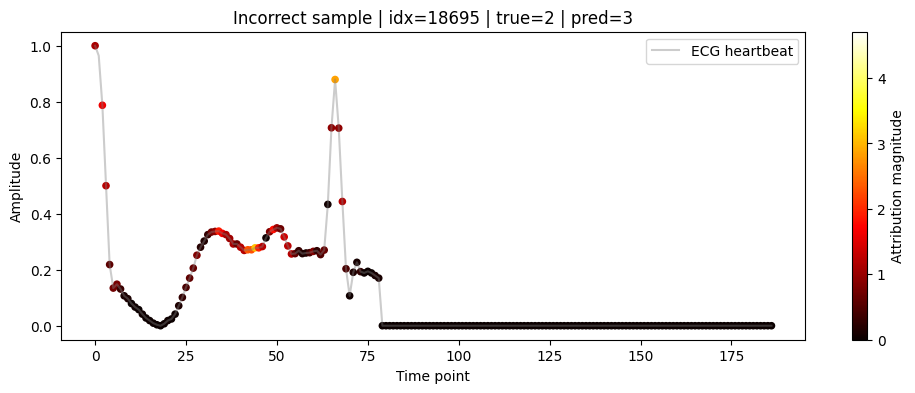

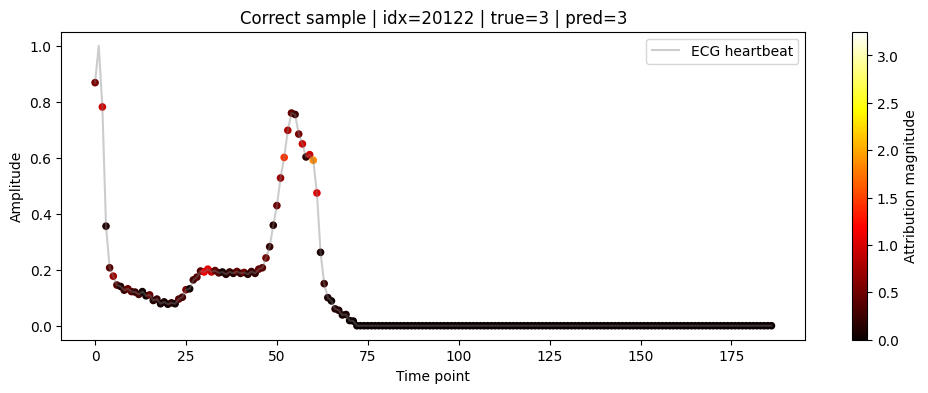

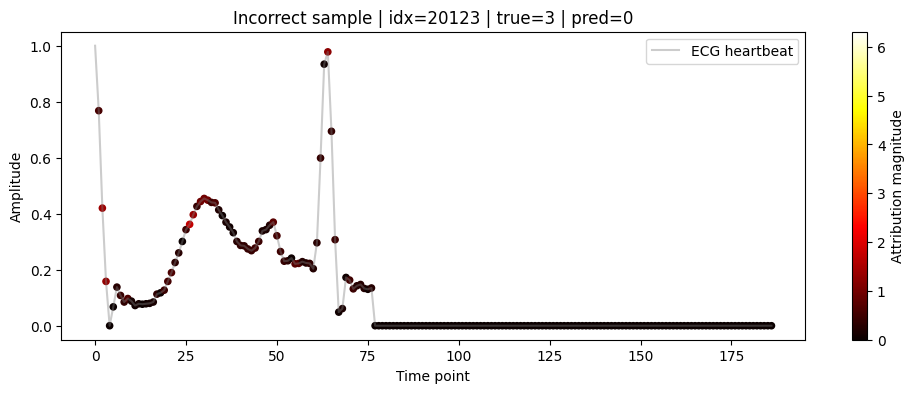

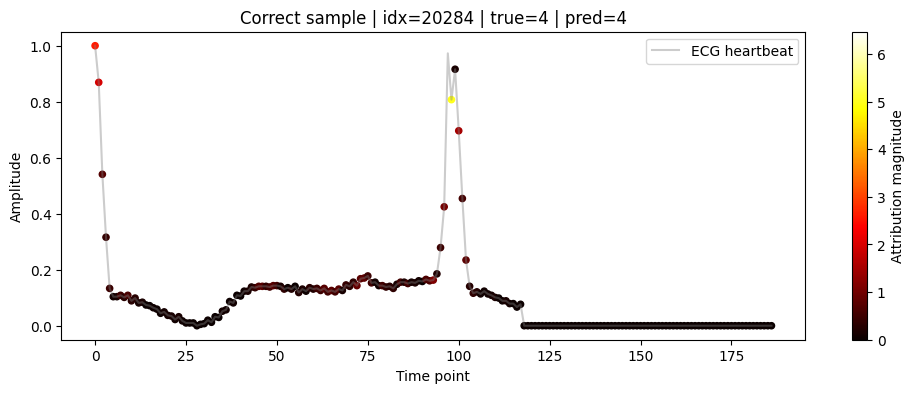

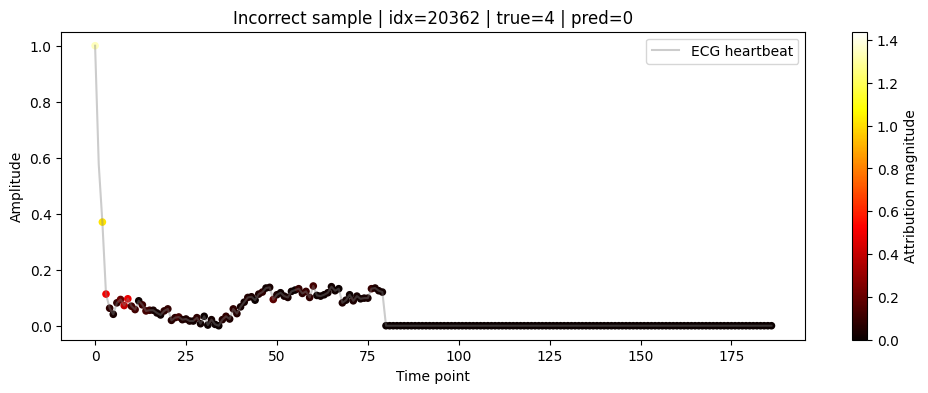

In [10]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from captum.attr import IntegratedGradients

model = learn.model
model.eval()

ig = IntegratedGradients(model)

# Predictions for entire test set
with torch.no_grad():
    X_test_tensor = torch.tensor(X_test).float().to(dls.device)
    preds = model(X_test_tensor)
    y_pred = preds.argmax(dim=1).cpu().numpy()

classes = np.unique(y_test)

for cls in classes:

    # First correctly classified sample of this class
    correct_idx = np.where((y_test == cls) & (y_pred == cls))[0]

    # First incorrectly classified sample whose true class is this class
    incorrect_idx = np.where((y_test == cls) & (y_pred != cls))[0]

    selected = []

    if len(correct_idx) > 0:
        selected.append(("Correct", correct_idx[0]))

    if len(incorrect_idx) > 0:
        selected.append(("Incorrect", incorrect_idx[0]))

    for label, sample_idx in selected:

        x = torch.tensor(
            X_test[sample_idx:sample_idx+1]
        ).float().to(dls.device)

        true_class = int(y_test[sample_idx])
        pred_class = int(y_pred[sample_idx])

        baseline = torch.zeros_like(x)

        # Explain the predicted class
        attr = ig.attribute(
            x,
            baselines=baseline,
            target=pred_class,
            n_steps=50
        )

        attr_np = attr.detach().cpu().numpy()[0, 0]
        signal_np = x.detach().cpu().numpy()[0, 0]

        plt.figure(figsize=(12, 4))


        plt.plot(
            signal_np,
            color="gray",
            alpha=0.4,
            linewidth=1.5,
            label="ECG heartbeat"
        )

        plt.scatter(
            np.arange(len(signal_np)),
            signal_np,
            c=np.abs(attr_np),
            cmap="hot",
            s=20
        )

        plt.colorbar(label="Attribution magnitude")
        plt.title(
            f"{label} sample | idx={sample_idx} | "
            f"true={true_class} | pred={pred_class}"
        )
        plt.xlabel("Time point")
        plt.ylabel("Amplitude")
        plt.legend()
        plt.show()